# Post-Lab Experiment: Regression Analysis on the California Housing Dataset

### Task: Perform a Regression Task on the California Housing Dataset


## Step 1: Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load the California Housing dataset from a public CSV repository
housing_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
housing_df = pd.read_csv(housing_url)

print("Dataset shape (rows, cols):", housing_df.shape)
print("\nMissing values per column:\n", housing_df.isnull().sum())
print("\nFirst 5 rows:")
housing_df.head()

Dataset shape (rows, cols): (20640, 10)

Missing values per column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# Basic statistical summary of the numeric columns
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Step 2: Handle Missing Values and Encode Categorical Feature

In [3]:
# 'total_bedrooms' has a few missing values -- fill them with the column median
housing_df["total_bedrooms"] = housing_df["total_bedrooms"].fillna(housing_df["total_bedrooms"].median())

# One-hot encode the categorical 'ocean_proximity' column
housing_df = pd.get_dummies(housing_df, columns=["ocean_proximity"], drop_first=True)

print("Missing values after imputation:", housing_df.isnull().sum().sum())
housing_df.head()

Missing values after imputation: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## Step 3: Prepare Features, Target, and Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split

# Separate independent features (X) from the target variable (y)
X = housing_df.drop(columns=["median_house_value"])
y = housing_df["median_house_value"]

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 16512
Testing samples : 4128


## Step 4: Feature Scaling

*Scaling is important for distance/margin based models such as SVR.*

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training mean (approx 0):", round(X_train_scaled.mean(), 4))
print("Scaled training std (approx 1):", round(X_train_scaled.std(), 4))

Scaled training mean (approx 0): 0.0
Scaled training std (approx 1): 1.0


## Task 1: Linear Regression
*Fit a Linear Regression model and generate predictions on the test set.*

In [6]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

print("Sample predictions:", np.round(lr_predictions[:5], 3))
print("Sample actual     :", y_test.values[:5])

Sample predictions: [ 54055.449 124225.339 255489.379 268002.432 262769.435]
Sample actual     : [ 47700.  45800. 500001. 218600. 278000.]


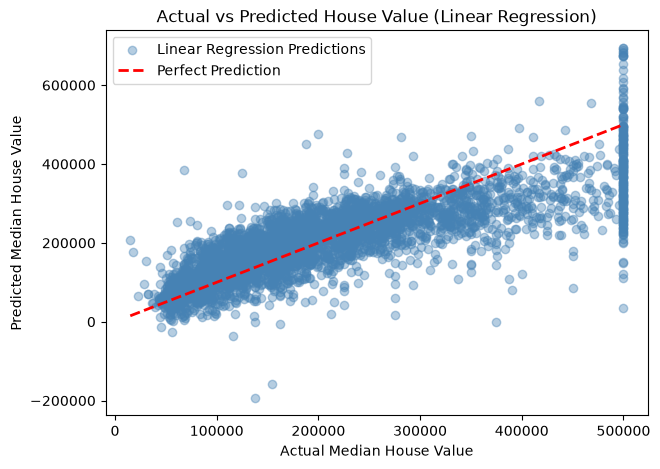

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, lr_predictions, color='steelblue', alpha=0.4, label='Linear Regression Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Actual vs Predicted House Value (Linear Regression)")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.legend()
plt.show()

## Task 2: Support Vector Regression and Decision Tree Regression
*Train SVR and Decision Tree models for a comparative performance analysis.*

In [8]:
from sklearn.svm import SVR

# SVR training cost grows quickly with sample size, so a random subsample
# of the training data is used to keep training time reasonable
rng = np.random.RandomState(42)
svr_sample_idx = rng.choice(X_train_scaled.shape[0], size=3000, replace=False)
X_train_svr = X_train_scaled[svr_sample_idx]
y_train_svr = y_train.iloc[svr_sample_idx]

svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_model.fit(X_train_svr, y_train_svr)
svr_predictions = svr_model.predict(X_test_scaled)

print("Sample SVR predictions:", np.round(svr_predictions[:5], 3))

Sample SVR predictions: [179469.905 180062.488 182906.134 183511.801 182893.881]


In [9]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_predictions = dt_model.predict(X_test_scaled)

print("Sample Decision Tree predictions:", np.round(dt_predictions[:5], 3))

Sample Decision Tree predictions: [ 60503.256  74269.962 365725.55  236746.25  231762.104]


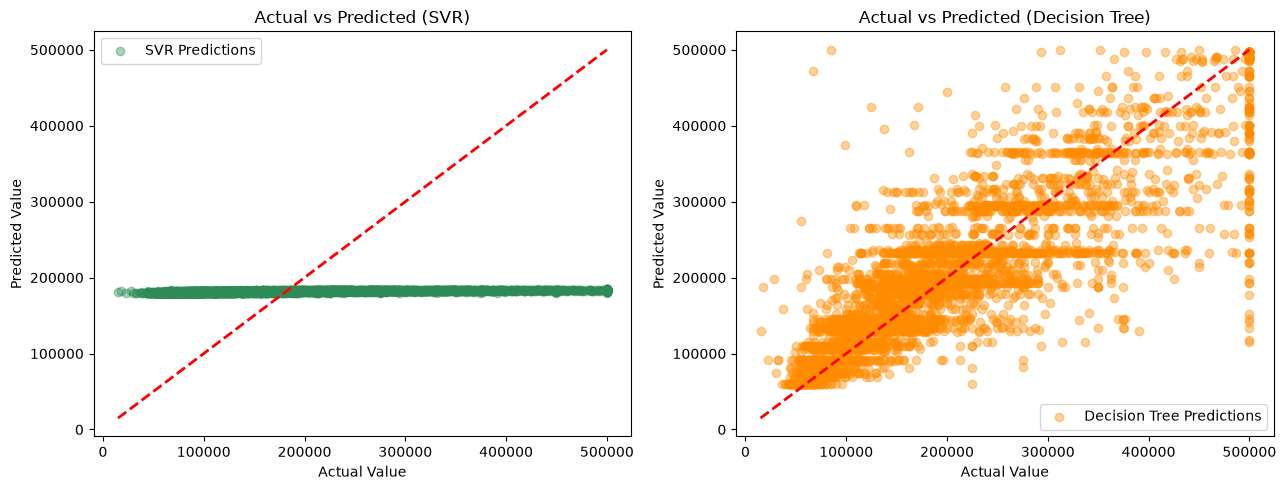

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(y_test, svr_predictions, color='seagreen', alpha=0.4, label='SVR Predictions')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Actual vs Predicted (SVR)")
axes[0].set_xlabel("Actual Value")
axes[0].set_ylabel("Predicted Value")
axes[0].legend()

axes[1].scatter(y_test, dt_predictions, color='darkorange', alpha=0.4, label='Decision Tree Predictions')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title("Actual vs Predicted (Decision Tree)")
axes[1].set_xlabel("Actual Value")
axes[1].set_ylabel("Predicted Value")
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 3: Learning Curves and Evaluation Metrics
*Diagnostic evaluation across all three models.*

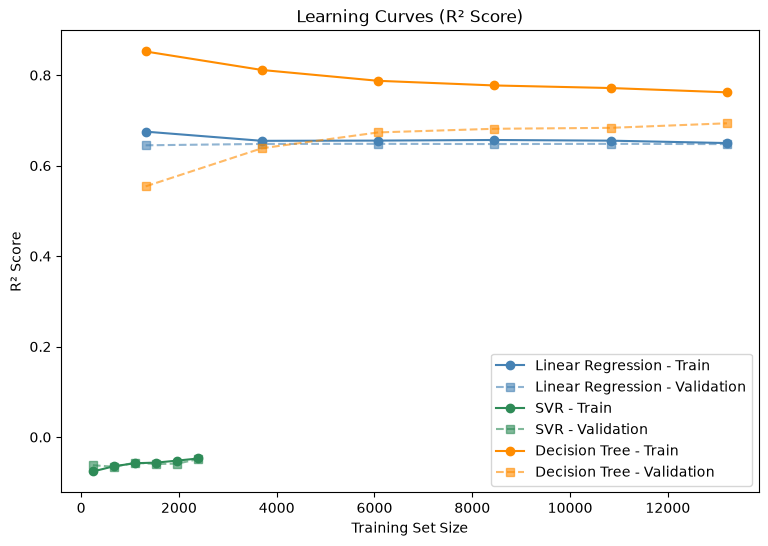

In [11]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, color):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 6), random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color=color, label=f'{title} - Train')
    plt.plot(train_sizes, val_mean, 's--', color=color, alpha=0.6, label=f'{title} - Validation')

plt.figure(figsize=(9,6))
plot_learning_curve(LinearRegression(), "Linear Regression", X_train_scaled, y_train, 'steelblue')
plot_learning_curve(SVR(kernel='rbf', C=10, epsilon=0.1), "SVR", X_train_svr, y_train_svr, 'seagreen')
plot_learning_curve(DecisionTreeRegressor(max_depth=8, random_state=42), "Decision Tree", X_train_scaled, y_train, 'darkorange')
plt.title("Learning Curves (R² Score)")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

lr_mae, lr_mse, lr_rmse, lr_r2 = get_metrics(y_test, lr_predictions)
svr_mae, svr_mse, svr_rmse, svr_r2 = get_metrics(y_test, svr_predictions)
dt_mae, dt_mse, dt_rmse, dt_r2 = get_metrics(y_test, dt_predictions)

performance = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression", "Decision Tree Regression"],
    "MAE": [lr_mae, svr_mae, dt_mae],
    "MSE": [lr_mse, svr_mse, dt_mse],
    "RMSE": [lr_rmse, svr_rmse, dt_rmse],
    "R\u00b2 Score": [lr_r2, svr_r2, dt_r2]
})

print("Regression Model Performance Comparison (California Housing Dataset)")
print(performance)

Regression Model Performance Comparison (California Housing Dataset)
                       Model           MAE           MSE           RMSE  \
0          Linear Regression  50670.738241  4.908477e+09   70060.521845   
1  Support Vector Regression  86678.930706  1.346960e+10  116058.586257   
2   Decision Tree Regression  42856.370789  3.945473e+09   62812.997150   

   R² Score  
0  0.625424  
1 -0.027892  
2  0.698913  


## Conclusion

In this experiment, Linear Regression, Support Vector Regression, and Decision Tree Regression models were trained on the California Housing dataset to predict median house values. Their performance was evaluated using MAE, MSE, RMSE, and R² score, along with learning curves to study bias-variance behaviour. The comparison highlights the trade-offs between the simplicity of linear models and the flexibility of non-linear models such as SVR and Decision Trees for this regression task.